In [4]:
from pathlib import Path
import pickle
import json

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [5]:
ROOT_DIR = Path("..").resolve()
DATA_DIR = ROOT_DIR / "data" / "EC3D"

SEQ_PATH = DATA_DIR / "ec3d_sequences.pkl"
SPLIT_PATH = DATA_DIR / "split_cross_subject.json"

with open(SEQ_PATH, "rb") as f:
    ec3d_data = pickle.load(f)

with open(SPLIT_PATH, "r") as f:
    split = json.load(f)

sequences = ec3d_data["sequences"]     # lista di np.array (T, 3, 25)
labels = ec3d_data["labels"]          # np.array (N_seq,) di global_label_id
meta = ec3d_data["meta"]              # lista di dict

train_indices = split["train_indices"]
test_indices = split["test_indices"]

print("Numero sequenze totali:", len(sequences))
print("Train:", len(train_indices), "Test:", len(test_indices))
print("Esempio sequence shape:", sequences[0].shape)
print("Esempio label:", labels[0], "meta:", meta[0])

Numero sequenze totali: 371
Train: 283 Test: 88
Esempio sequence shape: (64, 3, 25)
Esempio label: 6 meta: {'sequence_key': 'Lunges_Hugues_1_1', 'exercise': 'Lunges', 'subject': 'Hugues', 'instruction_id': 1, 'instruction_name': 'Correct', 'global_label_id': 6, 'global_label_name': 'Lunges - Correct', 'trial_id': 1, 'num_frames': 64}


In [6]:
def extract_features_from_sequence(seq: np.ndarray) -> np.ndarray:
    """
    seq: np.array shape (T, 3, 25)
    ritorna: feature vector 1D (dim ~ 225)
    """
    # Safety
    if seq.ndim != 3 or seq.shape[1] != 3:
        raise ValueError(f"Seq shape inattesa: {seq.shape}")

    # (T, 3, 25) -> (T, 25, 3) per comodità
    seq_t = np.transpose(seq, (0, 2, 1))  # (T, 25, 3)

    # Centra sul joint 0 (root/pelvis)
    root = seq_t[:, 0:1, :]  # (T, 1, 3)
    seq_centered = seq_t - root  # (T, 25, 3)

    # Calcoliamo statistiche nel tempo lungo l'asse T=0
    mean = seq_centered.mean(axis=0)        # (25, 3)
    std = seq_centered.std(axis=0)         # (25, 3)
    min_ = seq_centered.min(axis=0)        # (25, 3)
    max_ = seq_centered.max(axis=0)        # (25, 3)
    rng = max_ - min_                      # (25, 3)

    # Flatten in un unico vettore
    features = np.concatenate(
        [mean.flatten(), std.flatten(), rng.flatten()],
        axis=0
    )  # shape (25*3*3,) = 225

    return features.astype(np.float32)

In [7]:
# Estraiamo feature per tutte le sequenze
X = []
y = []

for seq, label in zip(sequences, labels):
    feats = extract_features_from_sequence(seq)
    X.append(feats)
    y.append(label)

X = np.stack(X, axis=0)          # (N_seq, D)
y = np.array(y, dtype=np.int64)  # (N_seq,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classi uniche:", np.unique(y))


X shape: (371, 225)
y shape: (371,)
Classi uniche: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [8]:
train_indices = np.array(train_indices, dtype=int)
test_indices = np.array(test_indices, dtype=int)

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (283, 225) Test shape: (88, 225)


In [9]:
# Standardizziamo le feature (media 0, varianza 1) usando solo il train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classificatore semplice
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

acc = (y_pred == y_test).mean()
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy (test): {acc:.3f}")
print(f"Macro-F1 (test): {macro_f1:.3f}")


Accuracy (test): 0.739
Macro-F1 (test): 0.679


Matplotlib is building the font cache; this may take a moment.


Classification report:
              precision    recall  f1-score   support

           0       0.29      0.20      0.24        10
           1       1.00      1.00      1.00         5
           2       0.50      0.20      0.29         5
           3       1.00      0.25      0.40         4
           4       0.38      0.86      0.52         7
           6       1.00      0.83      0.91        12
           7       0.91      1.00      0.95        10
           8       0.91      1.00      0.95        10
           9       1.00      0.29      0.44         7
          10       0.90      1.00      0.95         9
          11       0.69      1.00      0.82         9

    accuracy                           0.74        88
   macro avg       0.78      0.69      0.68        88
weighted avg       0.78      0.74      0.72        88

Confusion matrix shape: (11, 11)


<Figure size 1000x800 with 0 Axes>

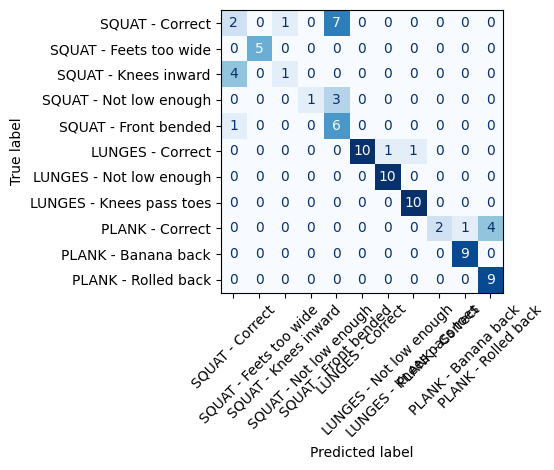

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix shape:", cm.shape)

# Etichette leggibili (opzionale)
id_to_name = {
    0: "SQUAT - Correct",
    1: "SQUAT - Feets too wide",
    2: "SQUAT - Knees inward",
    3: "SQUAT - Not low enough",
    4: "SQUAT - Front bended",
    5: "SQUAT - Unknown",
    6: "LUNGES - Correct",
    7: "LUNGES - Not low enough",
    8: "LUNGES - Knees pass toes",
    9: "PLANK - Correct",
    10: "PLANK - Banana back",
    11: "PLANK - Rolled back",
}

labels_names = [id_to_name[i] for i in sorted(np.unique(y_test))]

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
disp.plot(xticks_rotation=45, cmap="Blues", colorbar=False)
plt.tight_layout()
plt.show()


In [11]:
# Array con il nome dell'esercizio per ogni sequenza (stesso ordine di X)
exercise_per_seq = np.array([m["exercise"] for m in meta])

exercise_train = exercise_per_seq[train_indices]
exercise_test = exercise_per_seq[test_indices]

print("Esempio primi 10 esercizi train:", exercise_train[:10])
print("Esempio primi 10 esercizi test:", exercise_test[:10])


Esempio primi 10 esercizi train: ['Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges'
 'Lunges' 'Lunges']
Esempio primi 10 esercizi test: ['Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges' 'Lunges'
 'Lunges' 'Lunges']


In [12]:
# global_label_id delle classi "Correct" per ogni esercizio
CORRECT_LABEL = {
    "SQUAT": 0,
    "Lunges": 6,
    "Plank": 9,
}

S_ref = {}

for ex in ["SQUAT", "Lunges", "Plank"]:
    mask = (exercise_train == ex) & (y_train == CORRECT_LABEL[ex])
    n_seq = mask.sum()
    print(f"{ex}: sequenze corrette nel train = {n_seq}")
    
    # media delle feature scalate delle sequenze "Correct" di quell'esercizio
    S_ref[ex] = X_train_scaled[mask].mean(axis=0)

# Controllo veloce dimensioni
for ex, sig in S_ref.items():
    print(ex, sig.shape)


SQUAT: sequenze corrette nel train = 31
Lunges: sequenze corrette nel train = 34
Plank: sequenze corrette nel train = 26
SQUAT (225,)
Lunges (225,)
Plank (225,)


In [13]:
def build_signature_features(X_scaled, exercises, S_ref_dict):
    """
    X_scaled: (N, D) feature scalate
    exercises: array di stringhe ("SQUAT", "Lunges", "Plank") per ogni riga
    S_ref_dict: dizionario exercise -> firma corretta (D,)
    """
    X_sig = np.zeros_like(X_scaled)
    for i in range(X_scaled.shape[0]):
        ex = exercises[i]
        ref = S_ref_dict[ex]
        X_sig[i] = np.abs(X_scaled[i] - ref)
    return X_sig

X_train_sig = build_signature_features(X_train_scaled, exercise_train, S_ref)
X_test_sig = build_signature_features(X_test_scaled, exercise_test, S_ref)

print("X_train_sig shape:", X_train_sig.shape)
print("X_test_sig shape:", X_test_sig.shape)


X_train_sig shape: (283, 225)
X_test_sig shape: (88, 225)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_sig = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf_sig.fit(X_train_sig, y_train)

y_pred_sig = rf_sig.predict(X_test_sig)

acc_sig = (y_pred_sig == y_test).mean()
macro_f1_sig = f1_score(y_test, y_pred_sig, average="macro")

print(f"Baseline 1 (feature grezze)      - acc: {acc:.3f}, macro-F1: {macro_f1:.3f}")
print(f"Baseline 2 (delta da S_ref)      - acc: {acc_sig:.3f}, macro-F1: {macro_f1_sig:.3f}")


Baseline 1 (feature grezze)      - acc: 0.739, macro-F1: 0.679
Baseline 2 (delta da S_ref)      - acc: 0.693, macro-F1: 0.671


Confusion matrix (signature) shape: (11, 11)


<Figure size 1000x800 with 0 Axes>

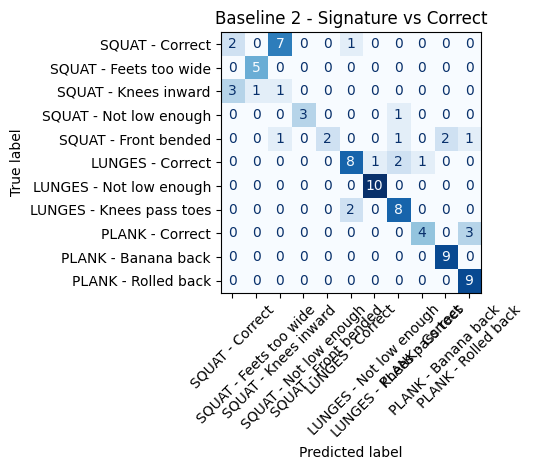

In [15]:
cm_sig = confusion_matrix(y_test, y_pred_sig)
print("Confusion matrix (signature) shape:", cm_sig.shape)

plt.figure(figsize=(10, 8))
disp_sig = ConfusionMatrixDisplay(confusion_matrix=cm_sig, display_labels=labels_names)
disp_sig.plot(xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline 2 - Signature vs Correct")
plt.tight_layout()
plt.show()


In [16]:
# Mapping globale id -> short name (già ce l'hai sopra, ma lo rifaccio pulito qui)
ID_TO_SHORT = {
    0: "SQUAT - Correct",
    1: "SQUAT - Feets too wide",
    2: "SQUAT - Knees inward",
    3: "SQUAT - Not low enough",
    4: "SQUAT - Front bended",
    5: "SQUAT - Unknown",
    6: "LUNGES - Correct",
    7: "LUNGES - Not low enough",
    8: "LUNGES - Knees pass toes",
    9: "PLANK - Correct",
    10: "PLANK - Banana back",
    11: "PLANK - Rolled back",
}

# Frasi di feedback in inglese, una per classe
ID_TO_FEEDBACK_EN = {
    0: "Your squat looks correct: neutral spine, knees tracking over toes and good depth.",
    1: "Your stance is too wide. Bring your feet slightly closer so they are about shoulder-width apart.",
    2: "Your knees are caving inward. Gently push them outward to keep them aligned with your feet.",
    3: "You are not squatting low enough. Try to sit a bit deeper while keeping your back neutral.",
    4: "You are bending your torso too far forward. Keep your chest up and your spine more upright.",
    5: "Your squat form is inconsistent. Focus on a stable stance and controlled movement.",
    6: "Your lunge form looks correct: stable step, good depth and front knee over the ankle.",
    7: "Your lunge is too shallow. Drop your back knee closer to the floor to increase the range of motion.",
    8: "Your front knee goes past your toes. Shorten your step or sit more downward instead of forward.",
    9: "Your plank looks correct: straight line from head to heels and engaged core.",
    10: "Your hips are too high in the plank. Lower them slightly to keep a straight line from shoulders to ankles.",
    11: "Your hips are dropping in the plank. Lift them a bit to avoid arching your lower back.",
}


In [18]:
for i in range(5):
    gid = int(labels[i])
    print(i, meta[i]["global_label_name"], "->", ID_TO_FEEDBACK_EN[gid])


0 Lunges - Correct -> Your lunge form looks correct: stable step, good depth and front knee over the ankle.
1 Lunges - Correct -> Your lunge form looks correct: stable step, good depth and front knee over the ankle.
2 Lunges - Correct -> Your lunge form looks correct: stable step, good depth and front knee over the ankle.
3 Lunges - Correct -> Your lunge form looks correct: stable step, good depth and front knee over the ankle.
4 Lunges - Correct -> Your lunge form looks correct: stable step, good depth and front knee over the ankle.
